In [ ]:
# !pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

base_path = "/content/drive/MyDrive/Elliptic_Dataset/"

features = pd.read_csv(base_path + "elliptic_txs_features.csv",header=None)
edges = pd.read_csv(base_path + "elliptic_txs_edgelist.csv")
classes = pd.read_csv(base_path + "elliptic_txs_classes.csv")

In [ ]:
import pandas as pd
import numpy as np
import torch
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler

In [ ]:
features.rename(columns={0: 'txId', 1: 'timestep'}, inplace=True)

# ==========================================
# LABEL ALIGNMENT
# ==========================================

df = pd.merge(features, classes, on='txId', how='inner')

# ==========================================
# LABEL MAPPING
# ==========================================
# Fraud (illicit) = 1, Normal (licit) = 0, Unknown = -1
label_mapping = {'1': 1, '2': 0, 'unknown': -1}
df['class'] = df['class'].map(label_mapping)

# ==========================================
# TEMPORAL SPLIT MASKS
# ==========================================
# Standard Elliptic Split: Timesteps 1-34 for Train, 35-49 for Test
train_mask = (df['timestep'] <= 34) & (df['class'] != -1)
val_mask = (df['timestep'] > 34) & (df['timestep'] <= 41) & (df['class'] != -1)
test_mask = (df['timestep'] > 41) & (df['class'] != -1)

# ==========================================
# TEMPORAL NORMALIZATION
# ==========================================

feature_cols = df.columns[2:-1]
scaler = StandardScaler()

# FIT TRAIN TIMESTEPS
train_timesteps_mask = df['timestep'] <= 34
scaler.fit(df.loc[train_timesteps_mask, feature_cols])


df[feature_cols] = scaler.transform(df[feature_cols])

# ==========================================
# VECTORIZED EDGE BUILDING
# ==========================================

tx_id_to_idx = {tx_id: idx for idx, tx_id in enumerate(df['txId'])}


edges['src_idx'] = edges['txId1'].map(tx_id_to_idx)
edges['dst_idx'] = edges['txId2'].map(tx_id_to_idx)


edges_clean = edges.dropna(subset=['src_idx', 'dst_idx']).astype(int)

edge_index = torch.tensor(edges_clean[['src_idx', 'dst_idx']].values.T, dtype=torch.long).contiguous()

# ==========================================
# CREATE PYG DATA OBJECT
# ==========================================
x_tensor = torch.tensor(df[feature_cols].values, dtype=torch.float)
y_tensor = torch.tensor(df['class'].values, dtype=torch.long)

data = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
data.train_mask = torch.tensor(train_mask.values, dtype=torch.bool)
data.val_mask = torch.tensor(val_mask.values, dtype=torch.bool)
data.test_mask = torch.tensor(test_mask.values, dtype=torch.bool)

# ==========================================
# HANDLE CLASS IMBALANCE
# ==========================================
train_labels = df.loc[train_mask, 'class']
class_counts = train_labels.value_counts().sort_index()
total_train = len(train_labels)

weight_class_0 = total_train / (2 * class_counts[0])
weight_class_1 = total_train / (2 * class_counts[1])
class_weights = torch.tensor([weight_class_0, weight_class_1], dtype=torch.float)

# ==========================================
# SUMMARY
# ==========================================
print("PyG Data Object:", data)
print(f"Train nodes (labeled): {data.train_mask.sum().item()}")
print(f"Val nodes (labeled):   {data.val_mask.sum().item()}")
print(f"Test nodes (labeled):  {data.test_mask.sum().item()}")
print(f"Class Weights [Normal, Fraud]: {class_weights.tolist()}")

PyG Data Object: Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])
Train nodes (labeled): 29894
Val nodes (labeled):   7829
Test nodes (labeled):  8841
Class Weights [Normal, Fraud]: [0.5654888153076172, 4.317446708679199]


Calculating layout for 7880 nodes and 9164 edges... Please wait.


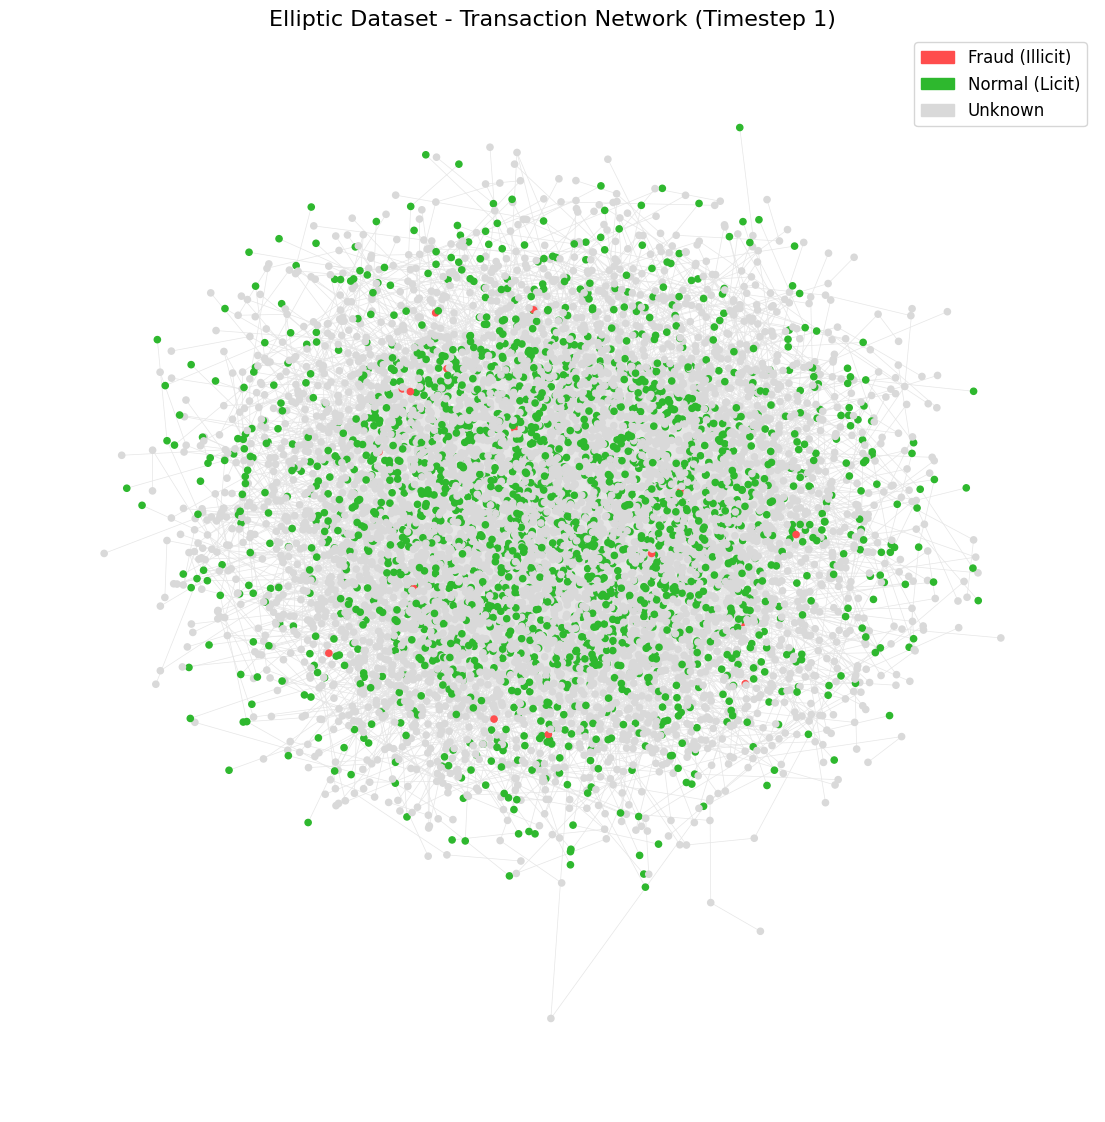

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

target_timestep = 1

nodes_t1 = df[df['timestep'] == target_timestep]
valid_tx_ids = set(nodes_t1['txId'])

edges_t1 = edges[(edges['txId1'].isin(valid_tx_ids)) & (edges['txId2'].isin(valid_tx_ids))]

# ==========================================
# BUILD THE NETWORKX GRAPH
# ==========================================
G = nx.DiGraph()


G.add_nodes_from(valid_tx_ids)
G.add_edges_from(zip(edges_t1['txId1'], edges_t1['txId2']))

# ==========================================
# COLOR MAPPING FOR LABELS
# ==========================================
# Fraud = 1 (Red), Normal = 0 (Green), Unknown = -1 (Gray)
color_map = {1: '#ff4d4d', 0: '#2eb82e', -1: '#d9d9d9'}

class_dict = dict(zip(nodes_t1['txId'], nodes_t1['class']))

node_colors = [color_map[class_dict[node]] for node in G.nodes()]

# ==========================================
# PLOTTING GRAPH
# ==========================================
plt.figure(figsize=(14, 14))
plt.title(f"Elliptic Dataset - Transaction Network (Timestep {target_timestep})", fontsize=16)

print(f"Calculating layout for {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
pos = nx.spring_layout(G, k=0.15, iterations=20, seed=42)

nx.draw(
    G, pos,
    node_color=node_colors,
    node_size=20,
    edge_color='#e6e6e6',
    width=0.5,
    with_labels=False,
    arrows=False
    )


fraud_patch = mpatches.Patch(color='#ff4d4d', label='Fraud (Illicit)')
normal_patch = mpatches.Patch(color='#2eb82e', label='Normal (Licit)')
unknown_patch = mpatches.Patch(color='#d9d9d9', label='Unknown')
plt.legend(handles=[fraud_patch, normal_patch, unknown_patch], loc='upper right', fontsize=12)

plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, global_mean_pool

class TemporalFraudGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4, dropout=0.5):
        super(TemporalFraudGNN, self).__init__()

        # ==========================================
        # SPATIAL BLOCK - Multi-Head Attention
        # ==========================================
        # heads=4
        self.gat1 = GATv2Conv(in_channels, hidden_channels, heads=heads, concat=True)
        self.bn1 = nn.BatchNorm1d(hidden_channels * heads)

        self.gat2 = GATv2Conv(hidden_channels * heads, hidden_channels, heads=1, concat=False)
        self.bn2 = nn.BatchNorm1d(hidden_channels)

        # ==========================================
        # TEMPORAL BLOCK - GRU Memory
        # ==========================================

        self.gru = nn.GRU(input_size=hidden_channels, hidden_size=hidden_channels, batch_first=True)

        # ==========================================
        # FUSION & UNCERTAINTY BLOCK: MLP + Dropout
        # ==========================================

        self.mlp = nn.Sequential(
            nn.Linear(hidden_channels * 2, hidden_channels),
            nn.LeakyReLU(0.2),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, out_channels)
        )
        self.dropout = dropout

    def forward(self, x, edge_index, batch, h_prev=None):

        # SPATIAL PASS
        x_spatial = self.gat1(x, edge_index)
        x_spatial = self.bn1(x_spatial)
        x_spatial = F.leaky_relu(x_spatial, 0.2)
        x_spatial = F.dropout(x_spatial, p=self.dropout, training=self.training)

        x_spatial = self.gat2(x_spatial, edge_index)
        x_spatial = self.bn2(x_spatial)
        x_spatial = F.leaky_relu(x_spatial, 0.2)
        x_spatial = F.dropout(x_spatial, p=self.dropout, training=self.training)

        # TEMPORAL PASS
        graph_summary = global_mean_pool(x_spatial, batch)
        graph_summary = graph_summary.unsqueeze(0)

        _, h_next = self.gru(graph_summary, h_prev)

        temporal_context = h_next.squeeze(0).expand(x_spatial.size(0), -1)

        # FUSION & CLASSIFICATION
        combined_features = torch.cat([x_spatial, temporal_context], dim=1)
        out = self.mlp(combined_features)
        return out, h_next

In [ ]:
def predict_with_uncertainty_temporal(model, x, edge_index, batch, h_prev, num_passes=50):
    model.train()
    predictions = []

    with torch.no_grad():
        for _ in range(num_passes):

            logits, _ = model(x, edge_index, batch, h_prev)
            probs = F.softmax(logits, dim=1)
            predictions.append(probs.unsqueeze(0))

    predictions = torch.cat(predictions, dim=0)

    # Calculate Mean Probability and Variance for Uncertainty
    mean_probs = predictions.mean(dim=0)
    uncertainty = predictions.var(dim=0).mean(dim=1)

    model.eval()
    with torch.no_grad():
        _, true_h_next = model(x, edge_index, batch, h_prev)

    return mean_probs, uncertainty, true_h_next

In [ ]:
from torch_geometric.utils import subgraph

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Preparing Temporal Snapshots...")

temporal_graphs = []

timesteps_tensor = torch.tensor(df['timestep'].values, device=data.edge_index.device)

for t in range(1, 50):
    node_idx = torch.where(timesteps_tensor == t)[0]
    edge_index_t, _ = subgraph(node_idx, data.edge_index, relabel_nodes=True)

    x_t = data.x[node_idx]
    y_t = data.y[node_idx]

    # Create mask (Fraud=1, Normal=0, Unknown=-1)
    labeled_mask = (y_t != -1)

    # Batch vector
    batch_t = torch.zeros(x_t.size(0), dtype=torch.long, device=data.x.device)

    temporal_graphs.append({
        'x': x_t.to(device),
        'edge_index': edge_index_t.to(device),
        'y': y_t.to(device),
        'mask': labeled_mask.to(device),
        'batch': batch_t.to(device)
    })

print(f"Created {len(temporal_graphs)} sequential graph snapshots.")

In [ ]:
import copy
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

# ==========================================
# MODEL SETUP
# ==========================================
model = TemporalFraudGNN(in_channels=165, hidden_channels=64, out_channels=2, heads=4, dropout=0.5).to(device)

# CLASS-WEIGHTED LOSS
weights = torch.tensor([1.0, 9.0], dtype=torch.float).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)

EPOCHS = 1900
PATIENCE = 390
# GRADIENT CLIPPING LIMIT
MAX_GRAD_NORM = 2.0

best_val_f1 = 0.0
best_epoch = 0
best_model_weights = None
patience_counter = 0

print("Starting Temporal Training (BPTT)...")

# ==========================================
# TRAINING LOOP SETUP
# ==========================================
for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()

    h_prev = None
    train_loss = 0

    # Train sequentially on Timesteps 1 to 34
    for t in range(34):
        graph = temporal_graphs[t]
        out, h_prev = model(graph['x'], graph['edge_index'], graph['batch'], h_prev)

        if graph['mask'].sum() > 0:
            train_loss += criterion(out[graph['mask']], graph['y'][graph['mask']])

    # Backpropagate
    train_loss.backward()

    # GRADIENT CLIPPING
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=MAX_GRAD_NORM)
    optimizer.step()

    # ==========================================
    # 3. VALIDATION LOOP: Timesteps 35 to 41
    # ==========================================
    model.eval()
    val_loss = 0
    val_preds, val_labels = [], []

    with torch.no_grad():
        h_prev = None
        for t in range(34):
            graph = temporal_graphs[t]
            _, h_prev = model(graph['x'], graph['edge_index'], graph['batch'], h_prev)

        for t in range(34, 41):
            graph = temporal_graphs[t]
            out, h_prev = model(graph['x'], graph['edge_index'], graph['batch'], h_prev)

            if graph['mask'].sum() > 0:
                val_loss += criterion(out[graph['mask']], graph['y'][graph['mask']]).item()
                val_preds.append(out[graph['mask']].argmax(dim=1).cpu())
                val_labels.append(graph['y'][graph['mask']].cpu())

    # Calculating Val F1
    val_preds = torch.cat(val_preds).numpy()
    val_labels = torch.cat(val_labels).numpy()
    val_f1 = f1_score(val_labels, val_preds, pos_label=1, zero_division=0)

    # ==========================================
    # EARLY STOPPING
    # ==========================================
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        patience_counter = 0
        best_model_weights = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val F1: {val_f1:.4f} | Patience: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\n[!] Early stopping at epoch {epoch}!")
        break

print(f"\nTraining Complete. Best Val F1: {best_val_f1:.4f} at Epoch {best_epoch}.")

# ==========================================
# 5. FINAL TEST EVALUATION (Timesteps 42 to 49)
# ==========================================
model.load_state_dict(best_model_weights)
model.eval()

test_preds, test_labels, test_probs = [], [], []

with torch.no_grad():
    # Rebuild memory all the way from Timestep 1 to 41!
    h_prev = None
    for t in range(41):
        graph = temporal_graphs[t]
        _, h_prev = model(graph['x'], graph['edge_index'], graph['batch'], h_prev)

    # Predict on Test Timesteps (42 to 49)
    for t in range(41, 49):
        graph = temporal_graphs[t]
        out, h_prev = model(graph['x'], graph['edge_index'], graph['batch'], h_prev)

        if graph['mask'].sum() > 0:
            probs = torch.softmax(out[graph['mask']], dim=1)[:, 1]
            test_probs.append(probs.cpu())
            test_preds.append(out[graph['mask']].argmax(dim=1).cpu())
            test_labels.append(graph['y'][graph['mask']].cpu())

test_preds = torch.cat(test_preds).numpy()
test_labels = torch.cat(test_labels).numpy()
test_probs = torch.cat(test_probs).numpy()

print(f"\n🔥 FINAL SOTA TEST METRICS (Class 1 - Fraud):")
print(f"Precision: {precision_score(test_labels, test_preds, pos_label=1):.4f}")
print(f"Recall:    {recall_score(test_labels, test_preds, pos_label=1):.4f}")
print(f"F1-Score:  {f1_score(test_labels, test_preds, pos_label=1):.4f}")
print(f"ROC-AUC:   {roc_auc_score(test_labels, test_probs):.4f}")

🚀 Starting Temporal Training (BPTT)...
Epoch 001 | Train Loss: 24.0743 | Val F1: 0.3187 | Patience: 0/390
Epoch 010 | Train Loss: 10.3005 | Val F1: 0.3619 | Patience: 1/390
Epoch 020 | Train Loss: 6.4166 | Val F1: 0.3583 | Patience: 11/390
Epoch 030 | Train Loss: 4.6506 | Val F1: 0.3980 | Patience: 0/390
Epoch 040 | Train Loss: 3.5282 | Val F1: 0.4157 | Patience: 0/390
Epoch 050 | Train Loss: 2.9623 | Val F1: 0.4545 | Patience: 0/390
Epoch 060 | Train Loss: 2.4623 | Val F1: 0.4892 | Patience: 5/390
Epoch 070 | Train Loss: 2.0989 | Val F1: 0.4974 | Patience: 15/390
Epoch 080 | Train Loss: 1.7804 | Val F1: 0.4838 | Patience: 25/390
Epoch 090 | Train Loss: 1.6436 | Val F1: 0.4731 | Patience: 35/390
Epoch 100 | Train Loss: 1.4752 | Val F1: 0.5192 | Patience: 2/390
Epoch 110 | Train Loss: 1.3224 | Val F1: 0.5374 | Patience: 4/390
Epoch 120 | Train Loss: 1.3076 | Val F1: 0.5178 | Patience: 14/390
Epoch 130 | Train Loss: 1.2974 | Val F1: 0.4989 | Patience: 24/390
Epoch 140 | Train Loss: 1.121

Running Temporal Monte Carlo Dropout (50 passes) for Uncertainty Estimation...


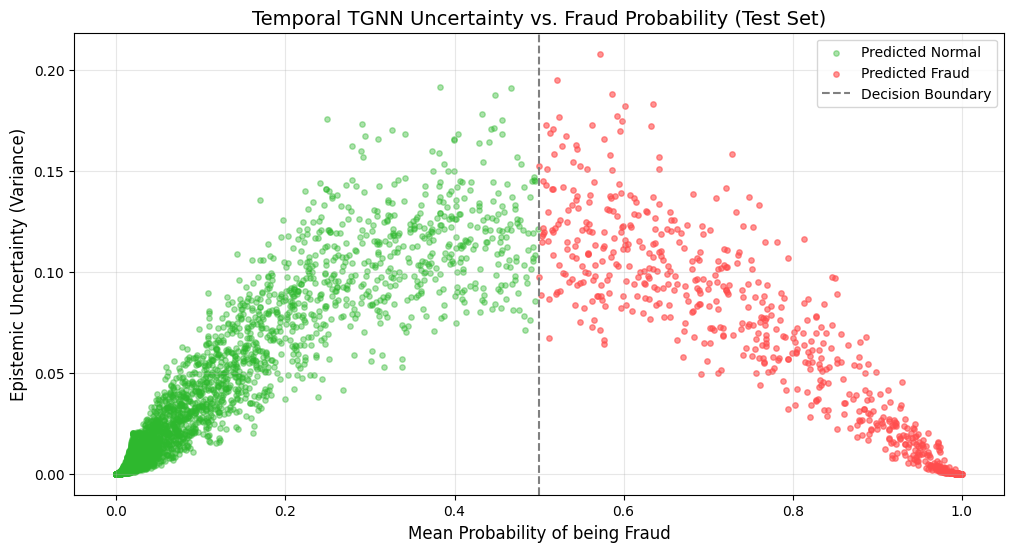


--- TEMPORAL UNCERTAINTY ANALYSIS ---
Average Uncertainty: 0.0173
Max Uncertainty: 0.2079
Number of 'Highly Uncertain' transactions (Top 5% variance): 443


In [ ]:
# ==========================================
# 2. RUN UNCERTAINTY ESTIMATION ON TEST TIMESTEPS
# ==========================================
print("Running Temporal Monte Carlo Dropout (50 passes) for Uncertainty Estimation...")

model.load_state_dict(best_model_weights)

test_unc_probs = []
test_unc_variances = []

with torch.no_grad():
    # Rebuild memory from Timestep 1 to 41
    h_prev = None
    model.eval()
    for t in range(41):
        graph = temporal_graphs[t]
        _, h_prev = model(graph['x'], graph['edge_index'], graph['batch'], h_prev)

    # Apply MC Dropout on Test Timesteps 42 to 49
    for t in range(41, 49):
        graph = temporal_graphs[t]

        mean_probs, uncertainty, h_prev = predict_with_uncertainty_temporal(
            model, graph['x'], graph['edge_index'], graph['batch'], h_prev, num_passes=50
        )

        if graph['mask'].sum() > 0:
            test_unc_probs.append(mean_probs[graph['mask']][:, 1].cpu())
            # Probability of Fraud
            test_unc_variances.append(uncertainty[graph['mask']].cpu())

test_unc_probs = torch.cat(test_unc_probs).numpy()
test_unc_variances = torch.cat(test_unc_variances).numpy()

# ==========================================
# SEPARATE PREDICTIONS & PLOT
# ==========================================
predicted_fraud_mask = test_unc_probs >= 0.5
predicted_normal_mask = test_unc_probs < 0.5

plt.figure(figsize=(12, 6))

# Plot Predicted Normal
plt.scatter(test_unc_probs[predicted_normal_mask],
            test_unc_variances[predicted_normal_mask],
            color='#2eb82e', alpha=0.4, label='Predicted Normal', s=15)

# Plot Predicted Fraud
plt.scatter(test_unc_probs[predicted_fraud_mask],
            test_unc_variances[predicted_fraud_mask],
            color='#ff4d4d', alpha=0.6, label='Predicted Fraud', s=15)

plt.axvline(x=0.5, color='gray', linestyle='--', label='Decision Boundary')
plt.title("Temporal TGNN Uncertainty vs. Fraud Probability (Test Set)", fontsize=14)
plt.xlabel("Mean Probability of being Fraud", fontsize=12)
plt.ylabel("Epistemic Uncertainty (Variance)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# 4. ANALYSIS
# ==========================================
high_uncertainty_threshold = np.percentile(test_unc_variances, 95)
highly_uncertain_nodes = np.sum(test_unc_variances >= high_uncertainty_threshold)

print(f"\n--- TEMPORAL UNCERTAINTY ANALYSIS ---")
print(f"Average Uncertainty: {test_unc_variances.mean():.4f}")
print(f"Max Uncertainty: {test_unc_variances.max():.4f}")
print(f"Number of 'Highly Uncertain' transactions (Top 5% variance): {highly_uncertain_nodes}")

In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

print("Optimizing Decision Threshold...")

# Calculate Precision, Recall, and F1 across ALL possible thresholds
precisions, recalls, thresholds = precision_recall_curve(test_labels, test_probs)

# Added 1e-8 to avoid division by zero
f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-8)

# Find the index of the highest F1-Score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
optimal_f1 = f1_scores[best_idx]
optimal_precision = precisions[best_idx]
optimal_recall = recalls[best_idx]

print("-" * 50)
print(f"OPTIMAL THRESHOLD FOUND: {best_threshold:.4f}")
print("-" * 50)
print(f"Adjusted Precision: {optimal_precision:.4f}")
print(f"Adjusted Recall:    {optimal_recall:.4f}")
print(f"Adjusted F1-Score:  {optimal_f1:.4f}")
print("-" * 50)

🔍 Optimizing Decision Threshold...
--------------------------------------------------
🌟 OPTIMAL THRESHOLD FOUND: 0.9857
--------------------------------------------------
Adjusted Precision: 0.5440
Adjusted Recall:    0.4240
Adjusted F1-Score:  0.4766 🔥
--------------------------------------------------


In [ ]:
# 2. Save the Model Weights
import os
save_dir = "/content/drive/MyDrive/Elliptic_Dataset/Saved_Models_And_Plots"
model_path = os.path.join(save_dir, 'best_robust_fraud_gnn_weights_with_class_weighted_loss_updated.pth')

torch.save(model.state_dict(), model_path)
print(f"Model weights successfully saved at: {model_path}")

✅ Model weights successfully saved at: /content/drive/MyDrive/Elliptic_Dataset/Saved_Models_And_Plots/best_robust_fraud_gnn_weights_with_class_weighted_loss.pth
